**AI Impact on the Job Market (2024–2030): Which Industries Will Gain or Lose Jobs?**

Artificial Intelligence is expected to reshape labor markets, but its effects are unlikely to be uniform across industries. This analysis investigates whether AI exposure, automation risk, and industry characteristics are associated with projected employment growth through 2030.





**Research Questions:**

Does automation risk predict job growth?

*   Do AI-impacted occupations grow faster?
*   Which industries benefit most from AI?
*   Which industries are most vulnerable?




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**UPLOAD DATASET**

In [6]:

from google.colab import files

uploaded = files.upload()

Saving ai_job_trends_dataset.csv to ai_job_trends_dataset.csv


In [8]:
# Load the dataset

df = pd.read_csv("ai_job_trends_dataset.csv")

**SECTION 2 - DATA UNDERSTANDING**

In [9]:
df.head()

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [10]:
df.shape

(30000, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job Title                    30000 non-null  object 
 1   Industry                     30000 non-null  object 
 2   Job Status                   30000 non-null  object 
 3   AI Impact Level              30000 non-null  object 
 4   Median Salary (USD)          30000 non-null  float64
 5   Required Education           30000 non-null  object 
 6   Experience Required (Years)  30000 non-null  int64  
 7   Job Openings (2024)          30000 non-null  int64  
 8   Projected Openings (2030)    30000 non-null  int64  
 9   Remote Work Ratio (%)        30000 non-null  float64
 10  Automation Risk (%)          30000 non-null  float64
 11  Location                     30000 non-null  object 
 12  Gender Diversity (%)         30000 non-null  float64
dtypes: float64(4), i

In [12]:
df.describe()

,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,90119.965639,10.051433,5039.640833,5074.218100,49.836431,50.154229,49.979660
std,34412.013953,6.060678,2861.009654,2866.550722,28.966688,28.754889,17.274665
min,30001.860000,0.000000,100.000000,100.000000,0.000000,0.000000,20.000000
25%,60500.702500,5.000000,2570.000000,2586.750000,24.570000,25.400000,35.070000
50%,90274.115000,10.000000,5034.000000,5106.500000,49.570000,50.020000,49.885000
75%,119454.710000,15.000000,7527.000000,7573.000000,75.100000,75.030000,64.910000
max,149998.500000,20.000000,10000.000000,10000.000000,100.000000,99.990000,80.000000


In [13]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [14]:
df.isnull().sum()

,0
Job Title,0
Industry,0
Job Status,0
AI Impact Level,0
Median Salary (USD),0
Required Education,0
Experience Required (Years),0
Job Openings (2024),0
Projected Openings (2030),0
Remote Work Ratio (%),0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Job Status"].value_counts()

,count
Job Status,
Increasing,15136
Decreasing,14864


In [17]:
df["Job Status"].value_counts(normalize=True) * 100

,proportion
Job Status,
Increasing,50.453333
Decreasing,49.546667


In [19]:
df["Growth_Rate"] = (
    (df["Projected Openings (2030)"] - df["Job Openings (2024)"])
    / df["Job Openings (2024)"]
) * 100

df["Growth_Rate"].describe()

,Growth_Rate
count,30000.000000
mean,141.035228
std,556.652294
min,-98.937049
25%,-49.366518
50%,0.303838
75%,97.583130
max,8945.098039


In [ ]:
### Analysis of the Growth rate result

If Mean = 141.04%
Median = 0.30%

If the average is 141% but the median is only 0.3%, it means a small number of observations have extremely large growth values that are pulling the mean upward.

With Max Growth Rate = 8945% and Std Dev = 556%. This suggests the distribution is heavily skewed.

**SECTION 3 - hYPOTHESEI 1**

Does Automation Risk Predict Growth?

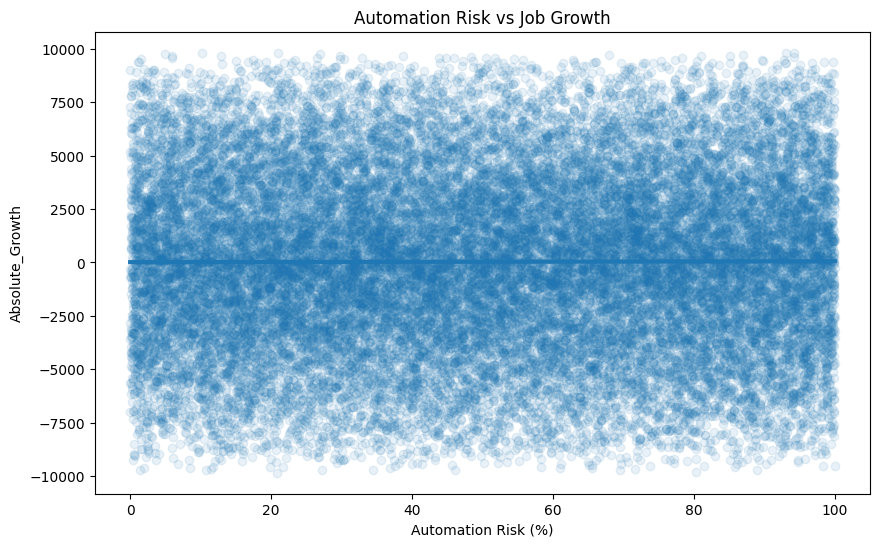

In [59]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="Automation Risk (%)",
    y="Absolute_Growth",
    scatter_kws={"alpha":0.1},
    line_kws={"linewidth":3}
)

plt.title(
    "Automation Risk vs Job Growth"
)

plt.show()

In [60]:
df["Automation Risk (%)"].corr(
    df["Absolute_Growth"]
)

np.float64(0.002938192107898129)

Analysis of Automation Risk and Projected Employment Growth revealed virtually no relationship between the two variables (r = 0.003). Despite common assumptions that highly automatable jobs will experience declining demand, the dataset suggests that automation risk alone does not explain projected job growth. Additional factors such as industry, AI impact level, education requirements, and labor market demand will likely play a more significant role.

**Automation risk alone does not explain projected employment growth.**

**Section 4 - Hypothesis 2**

Do AI-Impacted Jobs Grow Faster?

AI Impact Level
Low          4.214106
Moderate    31.274945
High        68.097151
Name: Absolute_Growth, dtype: float64


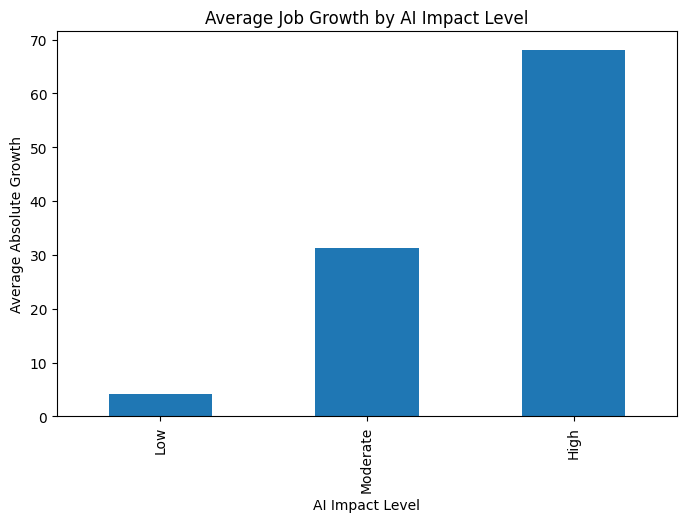

In [61]:
impact_growth = (
    df.groupby("AI Impact Level")["Absolute_Growth"]
      .mean()
      .sort_values()
)

print(impact_growth)

plt.figure(figsize=(8,5))
impact_growth.plot(kind="bar")

plt.title("Average Job Growth by AI Impact Level")
plt.ylabel("Average Absolute Growth")
plt.xlabel("AI Impact Level")

plt.show()

Occupations classified as having High AI Impact exhibit the strongest projected employment growth, averaging approximately 68 additional openings compared with only 4 additional openings among Low AI Impact occupations. This finding suggests that AI may act as a workforce transformation driver rather than solely a job displacement mechanism, with AI-intensive occupations demonstrating the strongest projected demand through 2030.

**High AI Impact jobs tend to have higher projected growth.**

**SECTION 5 - INDUSTRY EFFECT**

In [62]:
industry_ai = (
    df.pivot_table(
        values="Absolute_Growth",
        index="Industry",
        columns="AI Impact Level",
        aggfunc="mean"
    )
)

industry_ai

AI Impact Level,High,Low,Moderate
Industry,,,
Education,74.616846,-39.010260,-108.288835
Entertainment,162.529366,151.890400,-7.940789
Finance,-94.114806,45.685524,82.113854
Healthcare,148.484634,77.890777,93.699052
IT,74.962097,90.907916,254.635910
Manufacturing,58.661994,-36.397163,-12.795699
Retail,81.331452,-53.960599,158.258173
Transportation,36.621622,-202.586743,-198.239737


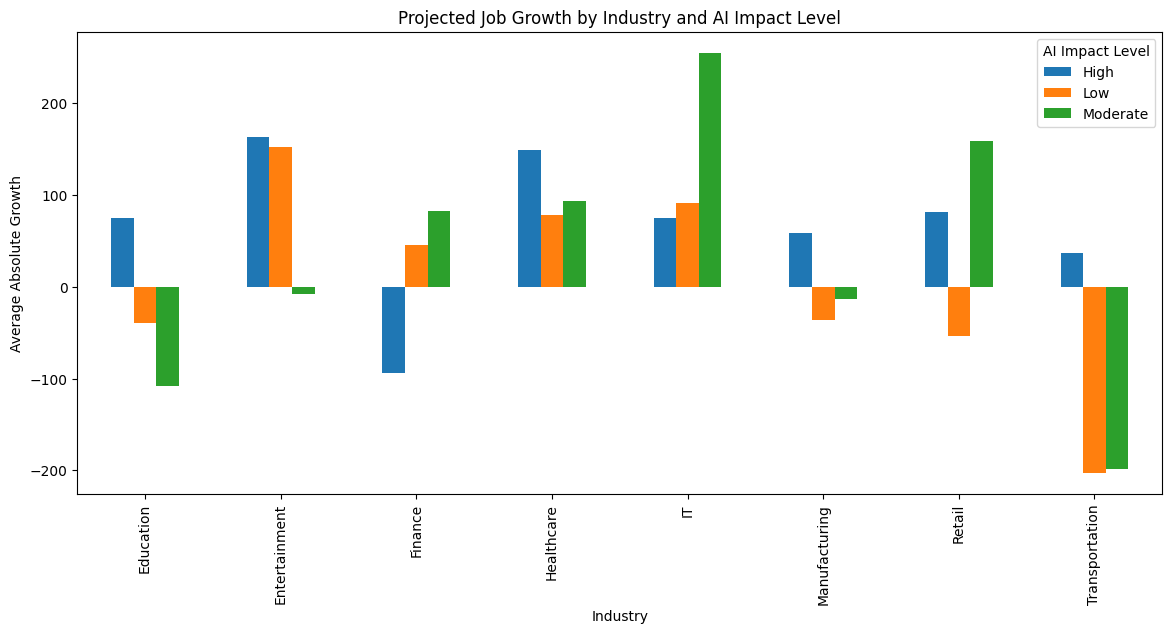

In [63]:
industry_ai.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title(
    "Projected Job Growth by Industry and AI Impact Level"
)

plt.ylabel("Average Absolute Growth")

plt.show()

In [64]:
for impact in ["High", "Moderate", "Low"]:

    print(f"\n{'='*50}")
    print(f"{impact.upper()} AI IMPACT")
    print(f"{'='*50}")

    display(
        industry_ai_stack[
            industry_ai_stack["AI_Impact"] == impact
        ]
        .sort_values("Growth", ascending=False)
        .reset_index(drop=True)
    )


HIGH AI IMPACT


,Industry,AI_Impact,Growth
0,Entertainment,High,162.529366
1,Healthcare,High,148.484634
2,Retail,High,81.331452
3,IT,High,74.962097
4,Education,High,74.616846
5,Manufacturing,High,58.661994
6,Transportation,High,36.621622
7,Finance,High,-94.114806



MODERATE AI IMPACT


,Industry,AI_Impact,Growth
0,IT,Moderate,254.635910
1,Retail,Moderate,158.258173
2,Healthcare,Moderate,93.699052
3,Finance,Moderate,82.113854
4,Entertainment,Moderate,-7.940789
5,Manufacturing,Moderate,-12.795699
6,Education,Moderate,-108.288835
7,Transportation,Moderate,-198.239737



LOW AI IMPACT


,Industry,AI_Impact,Growth
0,Entertainment,Low,151.890400
1,IT,Low,90.907916
2,Healthcare,Low,77.890777
3,Finance,Low,45.685524
4,Manufacturing,Low,-36.397163
5,Education,Low,-39.010260
6,Retail,Low,-53.960599
7,Transportation,Low,-202.586743


**Industry-Specific Effects of AI**

Analysis of projected job growth by Industry and AI Impact Level revealed substantial variation across sectors.

Key findings include:

IT occupations with Moderate AI Impact exhibited the highest projected growth (+255 openings on average). Healthcare maintained positive growth across all AI Impact categories. Transportation showed the largest projected declines, particularly among Low and Moderate AI Impact occupations. Finance displayed mixed outcomes, suggesting uneven workforce transformation. Entertainment demonstrated strong growth despite anticipated AI disruption.

These findings suggest that AI's workforce effects are industry-specific rather than universal, with some sectors experiencing expansion while others face contraction.

**SECTION 5.2 - GROWTH RATE BY INDUSTRY**

In [20]:
industry_growth = (
    df.groupby("Industry")["Growth_Rate"]
    .mean()
    .sort_values(ascending=False)
)

industry_growth

,Growth_Rate
Industry,
IT,176.568487
Finance,145.206940
Healthcare,144.356640
Entertainment,139.235385
Education,137.226116
Manufacturing,130.824994
Retail,130.538290
Transportation,124.791475


In [24]:
### Absolute Growth per industry

df["Absolute_Growth"] = (
    df["Projected Openings (2030)"]
    - df["Job Openings (2024)"]
)

df["Annual_Increase"] = (
    df["Absolute_Growth"] / 6
)

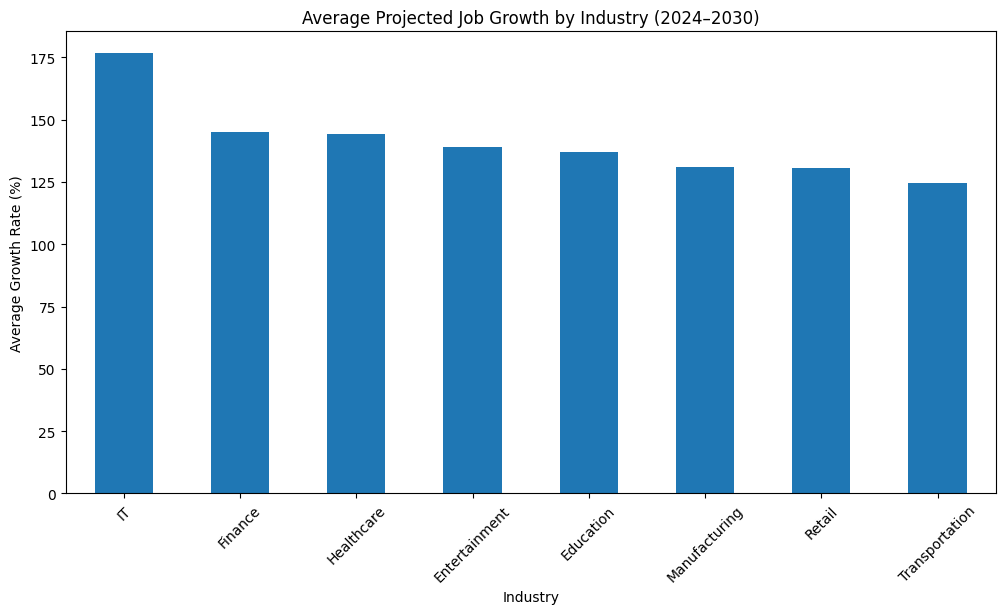

In [21]:
plt.figure(figsize=(12,6))

industry_growth.plot(kind="bar")

plt.title("Average Projected Job Growth by Industry (2024–2030)")
plt.xlabel("Industry")
plt.ylabel("Average Growth Rate (%)")

plt.xticks(rotation=45)

plt.show()

**Industry Growth Analysis**

The IT industry shows the highest projected growth rate (176.6%) between 2024 and 2030, significantly exceeding all other sectors.

Finance and Healthcare follow closely, both exceeding 144% projected growth.

Transportation shows the lowest projected growth (124.8%), though still positive.

A notable observation is that most industries fall within a relatively narrow growth range, suggesting that AI-driven workforce expansion may affect many sectors rather than being isolated to technology alone.


**The IT industry showing the strongest projected growth, suggests that AI is indeed creating demand for technical roles despite automation concerns.**

**Section 6: Hypothesis 3**


Are AI-Impacted Jobs Paid More?

AI Impact Level
High        90354.781024
Low         90265.040301
Moderate    89742.226538
Name: Median Salary (USD), dtype: float64


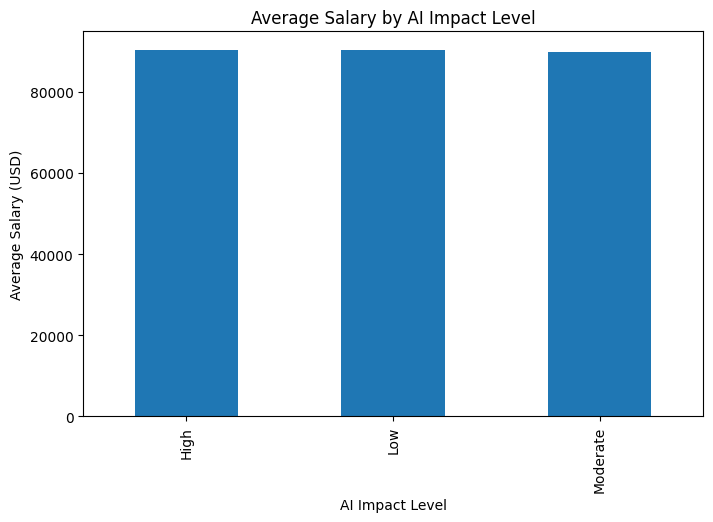

In [34]:
salary_growth = (
    df.groupby("AI Impact Level")
      ["Median Salary (USD)"]
      .mean()
)

print(salary_growth)

salary_growth.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Average Salary by AI Impact Level"
)

plt.ylabel("Average Salary (USD)")
plt.show()

In [35]:
df.groupby("AI Impact Level")["Median Salary (USD)"].describe()

,count,mean,std,min,25%,50%,75%,max
AI Impact Level,,,,,,,,
High,10005.0,90354.781024,34454.169396,30004.15,60501.7400,90915.98,119883.83,149983.06
Low,9953.0,90265.040301,34302.813152,30001.86,60948.9800,90421.98,119453.15,149997.75
Moderate,10042.0,89742.226538,34478.237884,30003.41,59995.4075,89709.11,119078.68,149998.50


In [53]:
from scipy import stats

groups = [df[df["AI Impact Level"] == lvl]["Median Salary (USD)"]
          for lvl in ["Low", "Moderate", "High"]]
f_stat, p_val = stats.f_oneway(*groups)
print(f"\nANOVA – salary across AI impact levels: F={f_stat:.4f}, p={p_val:.4f}")
if p_val < 0.05:
    print("  → Statistically significant difference in salaries across AI impact levels.")
else:
    print("  → No statistically significant salary difference across AI impact levels.")


ANOVA – salary across AI impact levels: F=0.9264, p=0.3960
  → No statistically significant salary difference across AI impact levels.


Despite substantial differences in projected job growth across AI Impact Levels, average salaries remained nearly identical. The largest difference between groups was less than 1%, suggesting that AI exposure is associated with employment demand rather than compensation.



In [44]:
# ── sklearn imports ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline

In [45]:
if "Growth_Rate" not in df.columns:
    df["Growth_Rate"] = (
        (df["Projected Openings (2030)"] - df["Job Openings (2024)"])
        / df["Job Openings (2024)"]
    ) * 100

if "Absolute_Growth" not in df.columns:
    df["Absolute_Growth"] = (
        df["Projected Openings (2030)"] - df["Job Openings (2024)"]
    )

**LOG-TRANSFORM & REGRESSION MODELLING**


3. LOG-TRANSFORM & REGRESSION MODELLING

Growth_Rate skewness (original): 7.0187
Log_Growth_Rate skewness (transformed): 0.0260


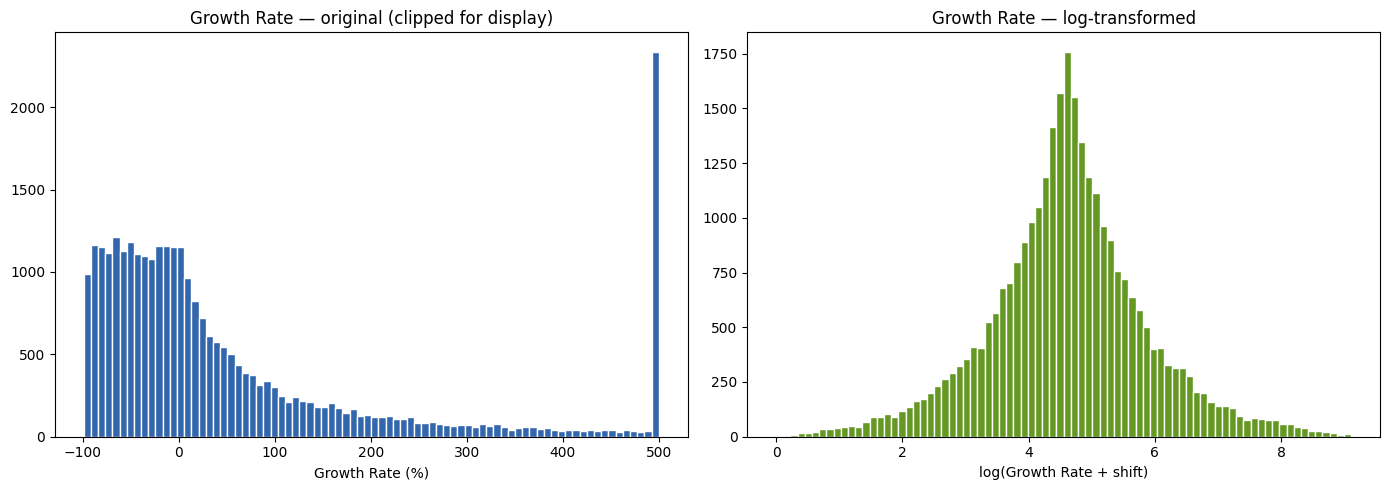

In [49]:
print("\n" + "="*60)
print("3. LOG-TRANSFORM & REGRESSION MODELLING")
print("="*60)

# Growth_Rate is heavily right-skewed — shift to positive then log-transform
shift = abs(df["Growth_Rate"].min()) + 1  # ensure all values > 0
df["Log_Growth_Rate"] = np.log(df["Growth_Rate"] + shift)

print(f"\nGrowth_Rate skewness (original): {df['Growth_Rate'].skew():.4f}")
print(f"Log_Growth_Rate skewness (transformed): {df['Log_Growth_Rate'].skew():.4f}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["Growth_Rate"].clip(-200, 500), bins=80, color="#3266ad", edgecolor="white")
axes[0].set_title("Growth Rate — original (clipped for display)")
axes[0].set_xlabel("Growth Rate (%)")

axes[1].hist(df["Log_Growth_Rate"], bins=80, color="#639922", edgecolor="white")
axes[1].set_title("Growth Rate — log-transformed")
axes[1].set_xlabel("log(Growth Rate + shift)")

plt.tight_layout()
plt.savefig("log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

reg_df = df[["Log_Growth_Rate", "Median Salary (USD)", "Experience Required (Years)",
             "Automation Risk (%)", "Remote Work Ratio (%)", "Gender Diversity (%)",
             "Job Openings (2024)", "Industry", "AI Impact Level", "Location"]].dropna()

# One-hot encode categoricals
cat_cols = ["Industry", "AI Impact Level", "Location"]
num_cols = ["Median Salary (USD)", "Experience Required (Years)",
            "Automation Risk (%)", "Remote Work Ratio (%)",
            "Gender Diversity (%)", "Job Openings (2024)"]

X_cat = pd.get_dummies(reg_df[cat_cols], drop_first=True)
X_num = reg_df[num_cols]
X = pd.concat([X_num, X_cat], axis=1)
y = reg_df["Log_Growth_Rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)

r2  = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nLinear regression on log(Growth_Rate):")
print(f"  R²   = {r2:.4f}")
print(f"  RMSE = {rmse:.4f}")


Linear regression on log(Growth_Rate):
  R²   = 0.4182
  RMSE = 0.9837


**LIMITATIONS SECTION**

*   Dataset appears synthetic.
*   Several variables exhibit near-zero correlations.
*   Results should be interpreted as patterns within this dataset rather than real-world forecasts.
*   Job Status labels were inconsistent with calculated growth metrics.

**EXECUTIVE SUMMARY**

**Key Findings from the dataset**

1. Automation Risk does not predict employment growth (r = 0.003).
2. High AI Impact occupations experience substantially greater projected growth than Low AI Impact occupations.
3. AI exposure does not correspond to higher salaries (ANOVA p = 0.396).
4. AI effects vary significantly by industry.
5. IT, Healthcare, and Entertainment appear best positioned for AI-driven expansion.
6. Transportation appears most vulnerable to contraction.